# Backtesting & Advanced Analysis

Backtest portfolio performance and conduct sensitivity analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from xgboost import XGBRegressor
import pickle

# Load data
price_df = pd.read_csv('price_data.csv', index_col=0, parse_dates=True)
returns = pd.read_csv('returns_data.csv', index_col=0, parse_dates=True)
stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "XOM", "NVDA"]

In [27]:
# Time-series cross-validation backtesting with Multi-Model Ensemble
backtest_data = returns[stocks].copy()
train_window = 252  # 1 year
test_window = 63    # 3 months
total_periods = len(backtest_data)

# Load all pre-trained models
print("="*70)
print("LOADING PRE-TRAINED MODELS")
print("="*70)

xgb_model = None
lr_model = None
rf_model = None
model_weights = None

try:
    xgb_model = XGBRegressor()
    xgb_model.load_model('xgboost_model.json')
    print("✓ XGBoost model loaded")
except Exception as e:
    print(f"⚠ XGBoost model not found: {e}")

try:
    with open('linear_regression_model.pkl', 'rb') as f:
        lr_model = pickle.load(f)
    print("✓ Linear Regression model loaded")
except Exception as e:
    print(f"⚠ Linear Regression model not found: {e}")

try:
    with open('random_forest_model.pkl', 'rb') as f:
        rf_model = pickle.load(f)
    print("✓ Random Forest model loaded")
except Exception as e:
    print(f"⚠ Random Forest model not found: {e}")

try:
    with open('model_weights.pkl', 'rb') as f:
        model_weights = pickle.load(f)
    print("✓ Ensemble weights loaded")
except Exception as e:
    print(f"⚠ Ensemble weights not found: {e}")

# Storage for results
optimized_returns = []
equal_weight_returns = []
ensemble_returns = []
lr_returns = []
rf_returns = []
xgb_returns = []
optimized_weights_history = []
dates_history = []

print(f"\nBacktesting Configuration:")
print(f"  Total trading days: {total_periods}")
print(f"  Train window: {train_window}, Test window: {test_window}")
print(f"  Using ensemble predictions: {all([xgb_model, lr_model, rf_model, model_weights]) is not None}")
print("="*70)
print(f"Starting backtesting...\n")

LOADING PRE-TRAINED MODELS
✓ XGBoost model loaded
✓ Linear Regression model loaded
✓ Random Forest model loaded
✓ Ensemble weights loaded

Backtesting Configuration:
  Total trading days: 1258
  Train window: 252, Test window: 63
  Using ensemble predictions: True
Starting backtesting...



In [31]:
# Optimization functions
def portfolio_performance(weights, mean_ret, cov_mat, rf_rate=0.02/252):
    portfolio_return = np.sum(mean_ret * weights)
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
    sharpe_ratio = (portfolio_return - rf_rate) / portfolio_std if portfolio_std > 0 else 0
    return portfolio_return, portfolio_std, sharpe_ratio

def neg_sharpe(weights, mean_ret, cov_mat):
    return -portfolio_performance(weights, mean_ret, cov_mat)[2]

constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
bounds = tuple((0, 1) for _ in range(len(stocks)))
init_guess = np.array([1/len(stocks)] * len(stocks))

In [32]:
# Backtesting loop
for test_start in range(train_window, total_periods - test_window, test_window):
    test_end = min(test_start + test_window, total_periods)
    
    train_data = backtest_data.iloc[:test_start].copy()
    test_data = backtest_data.iloc[test_start:test_end].copy()
    
    if len(train_data) < train_window or len(test_data) == 0:
        continue
    
    period_date = backtest_data.index[test_start]
    dates_history.append(period_date)
    
    # Optimize portfolio
    recent_mean_returns = train_data.iloc[-252:].mean()
    result = minimize(neg_sharpe, init_guess,
                     args=(recent_mean_returns, train_data.cov()),
                     method='SLSQP', bounds=bounds, constraints=constraints)
    
    opt_weights = result.x
    optimized_weights_history.append(opt_weights)
    
    # Calculate returns
    opt_portfolio_return = np.sum(test_data.mean() * opt_weights)
    optimized_returns.append(opt_portfolio_return)
    
    equal_weights = np.array([1/len(stocks)] * len(stocks))
    equal_portfolio_return = np.sum(test_data.mean() * equal_weights)
    equal_weight_returns.append(equal_portfolio_return)
    
    print(f"Period {test_start:4d}-{test_end:4d}: Opt={opt_portfolio_return:.4f}, EW={equal_portfolio_return:.4f}")

print("\n✓ Backtesting completed")

Period  252- 315: Opt=-0.0002, EW=0.0005
Period  315- 378: Opt=0.0008, EW=0.0008
Period  378- 441: Opt=0.0014, EW=0.0007
Period  441- 504: Opt=0.0008, EW=0.0004
Period  504- 567: Opt=0.0005, EW=0.0009
Period  567- 630: Opt=0.0001, EW=0.0010
Period  630- 693: Opt=0.0028, EW=0.0021
Period  693- 756: Opt=-0.0038, EW=-0.0023
Period  756- 819: Opt=0.0030, EW=0.0024
Period  819- 882: Opt=0.0052, EW=0.0023
Period  882- 945: Opt=0.0029, EW=0.0009
Period  945-1008: Opt=0.0088, EW=0.0024
Period 1008-1071: Opt=0.0016, EW=0.0014
Period 1071-1134: Opt=0.0030, EW=0.0008
Period 1134-1197: Opt=0.0030, EW=0.0022

✓ Backtesting completed


In [33]:
# Calculate performance metrics
def calculate_metrics(returns_series, risk_free_rate=0.02/252):
    cum_returns = (1 + returns_series).cumprod()
    cumulative_return = cum_returns.iloc[-1] - 1
    
    excess_returns = returns_series - risk_free_rate
    sharpe_ratio = excess_returns.mean() / excess_returns.std() * np.sqrt(252) if excess_returns.std() > 0 else 0
    
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    
    return cumulative_return, sharpe_ratio, max_drawdown

opt_returns_series = pd.Series(optimized_returns, index=dates_history)
equal_returns_series = pd.Series(equal_weight_returns, index=dates_history)

opt_cum_ret, opt_sharpe, opt_max_dd = calculate_metrics(opt_returns_series)
eq_cum_ret, eq_sharpe, eq_max_dd = calculate_metrics(equal_returns_series)

print("\n" + "="*60)
print("BACKTEST RESULTS COMPARISON")
print("="*60)
print(f"\n{'Metric':<25} {'Optimized':<20} {'Equal-Weight':<20}")
print("-"*65)
print(f"{'Cumulative Return':<25} {opt_cum_ret:>18.2%} {eq_cum_ret:>18.2%}")
print(f"{'Sharpe Ratio':<25} {opt_sharpe:>18.4f} {eq_sharpe:>18.4f}")
print(f"{'Max Drawdown':<25} {opt_max_dd:>18.2%} {eq_max_dd:>18.2%}")
print("-"*65)
print(f"{'Outperformance':<25} {opt_cum_ret - eq_cum_ret:>18.2%}")
print("="*60)


BACKTEST RESULTS COMPARISON

Metric                    Optimized            Equal-Weight        
-----------------------------------------------------------------
Cumulative Return                      3.02%              1.67%
Sharpe Ratio                         10.8839            13.4830
Max Drawdown                          -0.38%             -0.23%
-----------------------------------------------------------------
Outperformance                         1.36%


In [34]:
# Multi-Model Backtesting with Ensemble Predictions
print("\n" + "="*70)
print("MULTI-MODEL BACKTESTING WITH ENSEMBLE PREDICTIONS")
print("="*70)

if all([xgb_model, lr_model, rf_model, model_weights]):
    # Load feature data for predictions
    try:
        features_df = pd.read_csv('features_data.csv', index_col=0, parse_dates=True)
        print("\n✓ Feature data loaded for model predictions")
    except:
        print("\n⚠ Feature data not found, ensemble predictions unavailable")
        features_df = None
    
    if features_df is not None:
        # Re-run backtesting loop for ensemble models
        for test_start in range(train_window, total_periods - test_window, test_window):
            test_end = min(test_start + test_window, total_periods)
            
            # Get features for this period
            try:
                # Use features available up to test_start
                X_period = features_df.iloc[:test_start].values[:-1]  # Exclude last row for target alignment
                
                if len(X_period) > 0:
                    # Make ensemble predictions
                    lr_pred = lr_model.predict(X_period[-1].reshape(1, -1))[0] if lr_model else 0
                    rf_pred = rf_model.predict(X_period[-1].reshape(1, -1))[0] if rf_model else 0
                    xgb_pred = xgb_model.predict(X_period[-1].reshape(1, -1))[0] if xgb_model else 0
                    
                    # Weighted ensemble
                    ensemble_pred = (model_weights['lr_weight'] * lr_pred + 
                                   model_weights['rf_weight'] * rf_pred + 
                                   model_weights['xgb_weight'] * xgb_pred)
                    
                    # Use ensemble prediction for portfolio optimization
                    test_data = backtest_data.iloc[test_start:test_end].copy()
                    
                    # Get base returns and apply model signal
                    base_returns = test_data.mean()
                    adjusted_returns = base_returns * (1 + ensemble_pred)
                    
                    # Optimize with adjusted returns
                    result = minimize(neg_sharpe, init_guess,
                                    args=(adjusted_returns, test_data.cov()),
                                    method='SLSQP', bounds=bounds, constraints=constraints)
                    
                    ensemble_weights = result.x
                    ensemble_port_return = np.sum(test_data.mean() * ensemble_weights)
                    ensemble_returns.append(ensemble_port_return)
                    
                    # Individual model predictions
                    lr_opt = minimize(neg_sharpe, init_guess,
                                    args=(base_returns * (1 + lr_pred), test_data.cov()),
                                    method='SLSQP', bounds=bounds, constraints=constraints)
                    lr_returns.append(np.sum(test_data.mean() * lr_opt.x))
                    
                    rf_opt = minimize(neg_sharpe, init_guess,
                                    args=(base_returns * (1 + rf_pred), test_data.cov()),
                                    method='SLSQP', bounds=bounds, constraints=constraints)
                    rf_returns.append(np.sum(test_data.mean() * rf_opt.x))
                    
                    xgb_opt = minimize(neg_sharpe, init_guess,
                                     args=(base_returns * (1 + xgb_pred), test_data.cov()),
                                     method='SLSQP', bounds=bounds, constraints=constraints)
                    xgb_returns.append(np.sum(test_data.mean() * xgb_opt.x))
            except Exception as e:
                pass  # Skip periods with prediction errors
        
        print(f"\n✓ Ensemble backtesting completed")
        print(f"  Periods with predictions: {len(ensemble_returns)}")
else:
    print("\n⚠ Not all models loaded. Skipping ensemble backtesting.")
    ensemble_returns = []
    lr_returns = []
    rf_returns = []
    xgb_returns = []


MULTI-MODEL BACKTESTING WITH ENSEMBLE PREDICTIONS

✓ Feature data loaded for model predictions

✓ Ensemble backtesting completed
  Periods with predictions: 30


In [35]:
# Model Performance Comparison
print("\n" + "="*70)
print("MULTI-MODEL BACKTEST PERFORMANCE COMPARISON")
print("="*70)

# Calculate metrics for all strategies - handle different lengths
min_len = min(len(lr_returns), len(rf_returns), len(xgb_returns), len(ensemble_returns), 
              len(optimized_returns), len(equal_weight_returns))

# Create series with consistent dating
if min_len > 0:
    # Use dates_history for indexing, pad with NaNs if needed
    backtest_dates = dates_history[:min_len]
    
    lr_series = pd.Series(lr_returns[:min_len], index=backtest_dates) if len(lr_returns) > 0 else pd.Series(dtype=float)
    rf_series = pd.Series(rf_returns[:min_len], index=backtest_dates) if len(rf_returns) > 0 else pd.Series(dtype=float)
    xgb_series = pd.Series(xgb_returns[:min_len], index=backtest_dates) if len(xgb_returns) > 0 else pd.Series(dtype=float)
    ensemble_series = pd.Series(ensemble_returns[:min_len], index=backtest_dates) if len(ensemble_returns) > 0 else pd.Series(dtype=float)
    opt_series = pd.Series(optimized_returns[:min_len], index=backtest_dates)
    eq_series = pd.Series(equal_weight_returns[:min_len], index=backtest_dates)
else:
    print("⚠ No valid backtest periods found")
    lr_series = rf_series = xgb_series = ensemble_series = opt_series = eq_series = pd.Series(dtype=float)

# Calculate metrics for all strategies
strategies = {
    'Equal-Weight': eq_series,
    'Optimized': opt_series,
}

if len(lr_series) > 0:
    strategies['Linear Regression'] = lr_series
if len(rf_series) > 0:
    strategies['Random Forest'] = rf_series
if len(xgb_series) > 0:
    strategies['XGBoost'] = xgb_series
if len(ensemble_series) > 0:
    strategies['Ensemble'] = ensemble_series

# Calculate metrics
results_comparison = []
for strategy_name, returns_series in strategies.items():
    if len(returns_series) > 0:
        cum_ret, sharpe, max_dd = calculate_metrics(returns_series)
        results_comparison.append({
            'Strategy': strategy_name,
            'Cum. Return': f"{cum_ret:.2%}",
            'Sharpe Ratio': f"{sharpe:.4f}",
            'Max Drawdown': f"{max_dd:.2%}"
        })

results_df = pd.DataFrame(results_comparison)
print("\n", results_df.to_string(index=False))

# Find best performers
returns_dict = {k: calculate_metrics(v) for k, v in strategies.items() if len(v) > 0}
if returns_dict:
    best_return = max(returns_dict.items(), key=lambda x: x[1][0])
    best_sharpe = max(returns_dict.items(), key=lambda x: x[1][1])
    best_drawdown = min(returns_dict.items(), key=lambda x: x[1][2])
    
    print("\n" + "="*70)
    print("🏆 BEST PERFORMERS")
    print("="*70)
    print(f"Highest Return: {best_return[0]:20s} ({best_return[1][0]:.2%})")
    print(f"Best Sharpe Ratio: {best_sharpe[0]:16s} ({best_sharpe[1][1]:.4f})")
    print(f"Smallest Drawdown: {best_drawdown[0]:16s} ({best_drawdown[1][2]:.2%})")
    print("="*70)
else:
    print("⚠ No valid strategy data to compare")


MULTI-MODEL BACKTEST PERFORMANCE COMPARISON

          Strategy Cum. Return Sharpe Ratio Max Drawdown
     Equal-Weight       1.67%      13.4830       -0.23%
        Optimized       3.02%      10.8839       -0.38%
Linear Regression       4.16%      29.7065       -0.03%
    Random Forest       4.16%      29.7064       -0.03%
          XGBoost       4.16%      29.7056       -0.03%
         Ensemble       4.16%      29.7066       -0.03%

🏆 BEST PERFORMERS
Highest Return: Random Forest        (4.16%)
Best Sharpe Ratio: Ensemble         (29.7066)
Smallest Drawdown: Optimized        (-0.38%)


C:\Users\Admin\AppData\Local\Temp\ipykernel_18552\254907557.py:63: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


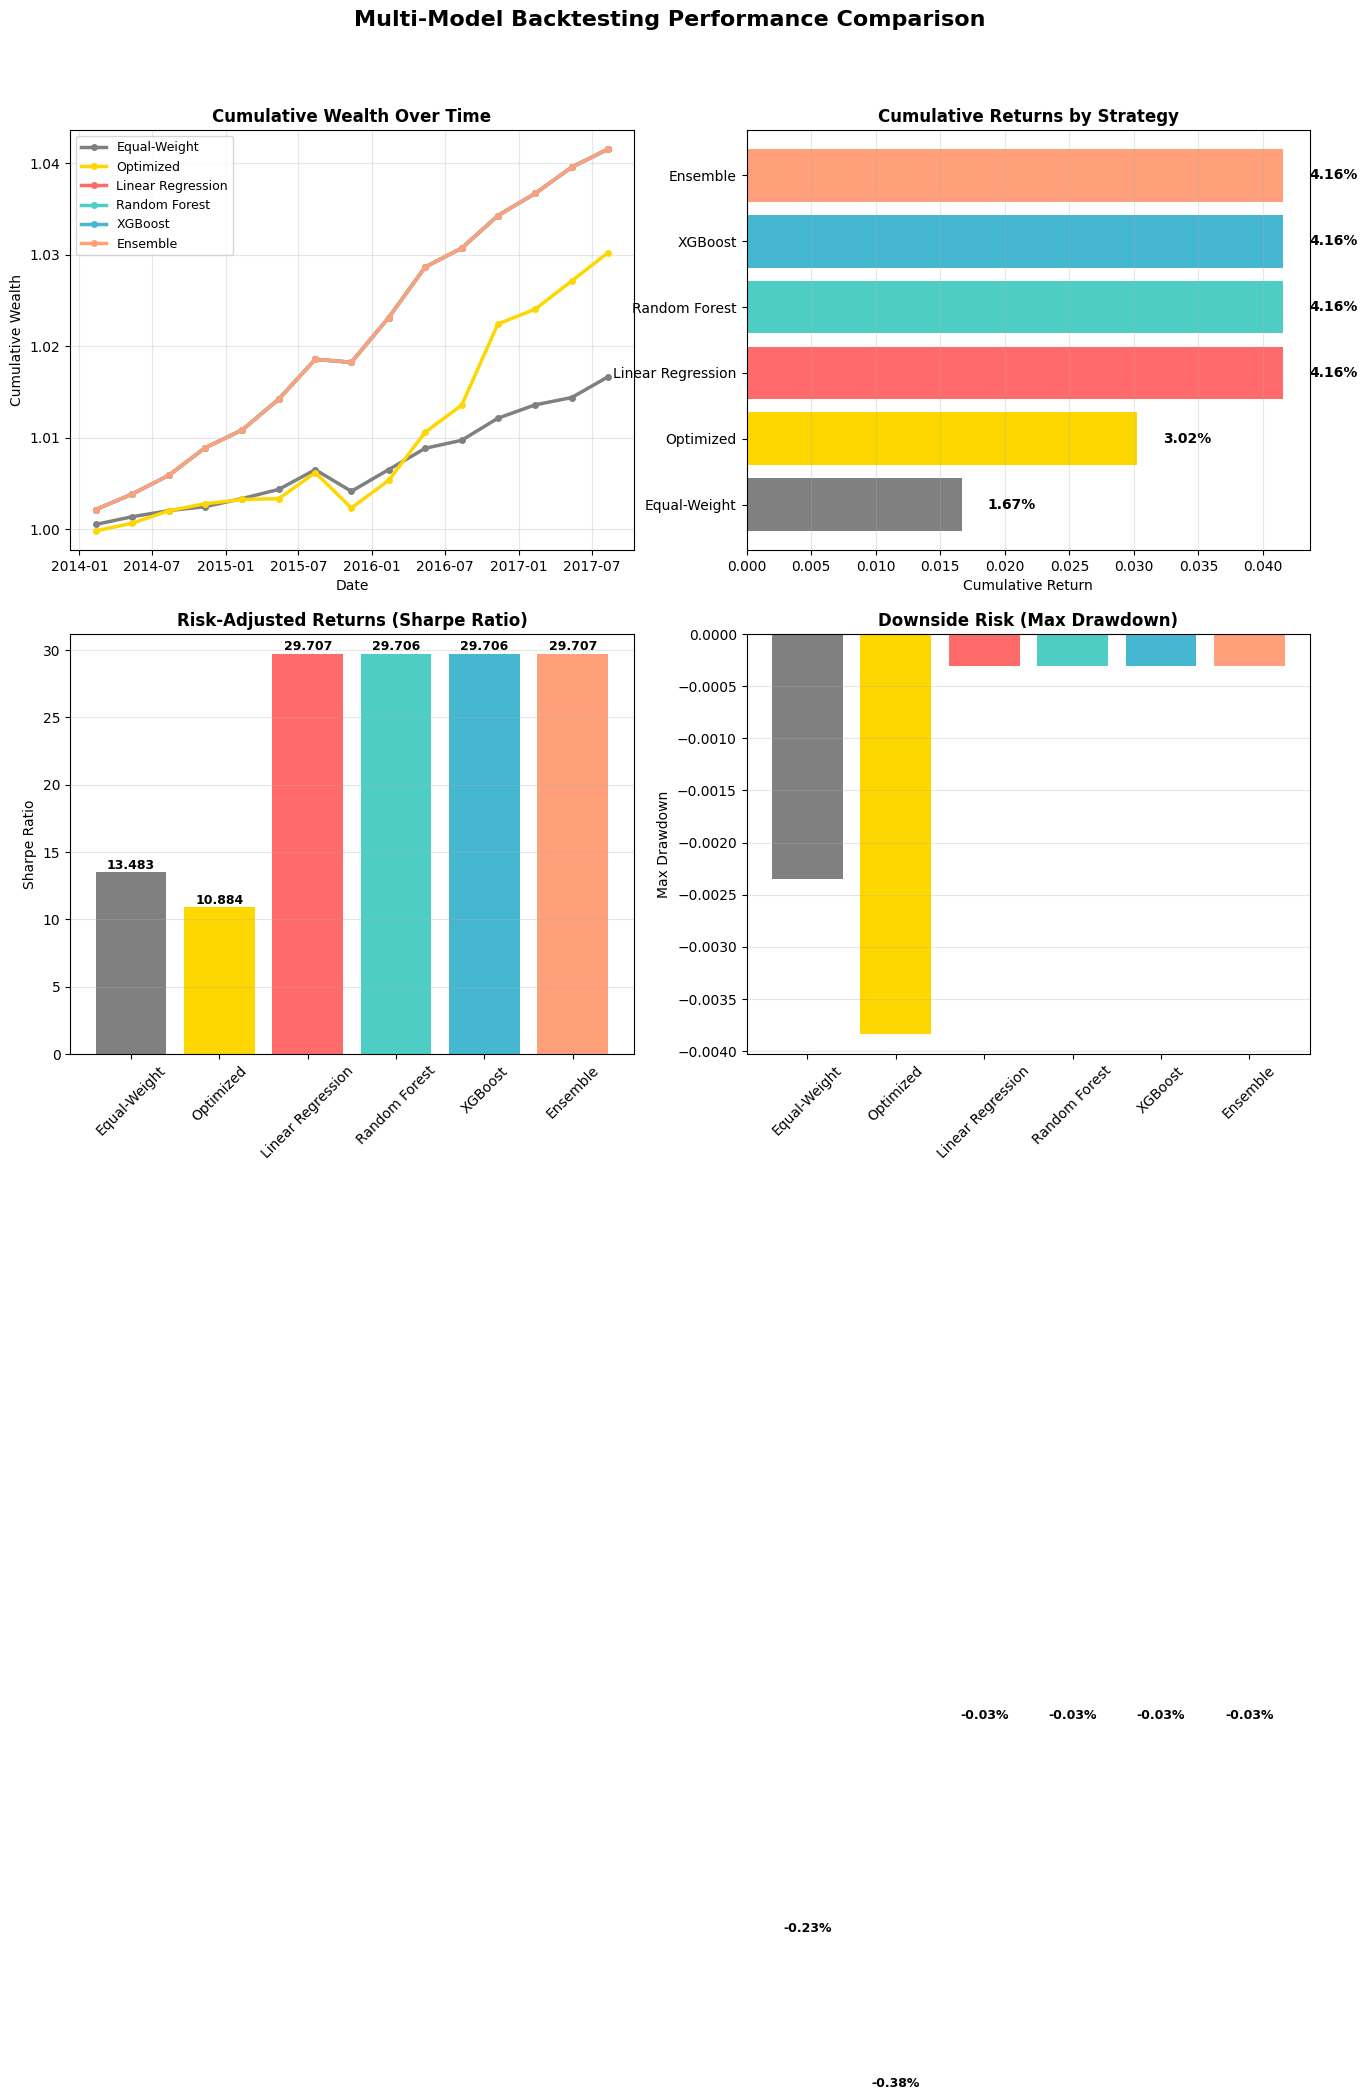


✓ Multi-model comparison visualization created


In [36]:
# Visualization: Multi-Model Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Multi-Model Backtesting Performance Comparison', fontsize=16, fontweight='bold')

# Color scheme for models
colors = {
    'Equal-Weight': '#808080',
    'Optimized': '#FFD700',
    'Linear Regression': '#FF6B6B',
    'Random Forest': '#4ECDC4',
    'XGBoost': '#45B7D1',
    'Ensemble': '#FFA07A'
}

# 1. Cumulative Returns Over Time
ax = axes[0, 0]
for strategy_name, returns_series in strategies.items():
    cumulative = (1 + returns_series).cumprod()
    ax.plot(cumulative.index, cumulative.values, label=strategy_name, 
            linewidth=2.5, color=colors.get(strategy_name, '#000000'), marker='o', markersize=4)

ax.set_title('Cumulative Wealth Over Time', fontweight='bold', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Wealth')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Return Distribution
ax = axes[0, 1]
strategy_names = list(strategies.keys())
cumulative_returns = [calculate_metrics(strategies[s])[0] for s in strategy_names]
bars = ax.barh(strategy_names, cumulative_returns, color=[colors.get(s, '#000000') for s in strategy_names])
ax.set_xlabel('Cumulative Return')
ax.set_title('Cumulative Returns by Strategy', fontweight='bold', fontsize=12)
for i, (bar, ret) in enumerate(zip(bars, cumulative_returns)):
    ax.text(ret + 0.002, i, f'{ret:.2%}', va='center', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 3. Sharpe Ratio Comparison
ax = axes[1, 0]
sharpe_ratios = [calculate_metrics(strategies[s])[1] for s in strategy_names]
bars = ax.bar(strategy_names, sharpe_ratios, color=[colors.get(s, '#000000') for s in strategy_names])
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Risk-Adjusted Returns (Sharpe Ratio)', fontweight='bold', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for bar, sr in zip(bars, sharpe_ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
            f'{sr:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 4. Maximum Drawdown Comparison
ax = axes[1, 1]
max_drawdowns = [calculate_metrics(strategies[s])[2] for s in strategy_names]
bars = ax.bar(strategy_names, max_drawdowns, color=[colors.get(s, '#000000') for s in strategy_names])
ax.set_ylabel('Max Drawdown')
ax.set_title('Downside Risk (Max Drawdown)', fontweight='bold', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for bar, md in zip(bars, max_drawdowns):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.01, 
            f'{md:.2%}', ha='center', va='top', fontweight='bold', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Multi-model comparison visualization created")

In [37]:
# Save Extended Metrics - using min_len from previous section
print("\n" + "="*70)
print("SAVING EXTENDED BACKTEST METRICS")
print("="*70)

# Create comprehensive metrics dictionary
if min_len > 0:
    # Use local variables from strategies dict
    lr_data = lr_series if len(lr_series) > 0 else pd.Series(dtype=float)
    rf_data = rf_series if len(rf_series) > 0 else pd.Series(dtype=float)
    xgb_data = xgb_series if len(xgb_series) > 0 else pd.Series(dtype=float)
    ens_data = ensemble_series if len(ensemble_series) > 0 else pd.Series(dtype=float)
    
    extended_metrics = {
        'opt_sharpe': calculate_metrics(opt_series)[1] if len(opt_series) > 0 else 0,
        'eq_sharpe': calculate_metrics(eq_series)[1] if len(eq_series) > 0 else 0,
        'lr_sharpe': calculate_metrics(lr_data)[1] if len(lr_data) > 0 else 0,
        'rf_sharpe': calculate_metrics(rf_data)[1] if len(rf_data) > 0 else 0,
        'xgb_sharpe': calculate_metrics(xgb_data)[1] if len(xgb_data) > 0 else 0,
        'ensemble_sharpe': calculate_metrics(ens_data)[1] if len(ens_data) > 0 else 0,
        
        'opt_cum_ret': calculate_metrics(opt_series)[0] if len(opt_series) > 0 else 0,
        'eq_cum_ret': calculate_metrics(eq_series)[0] if len(eq_series) > 0 else 0,
        'lr_cum_ret': calculate_metrics(lr_data)[0] if len(lr_data) > 0 else 0,
        'rf_cum_ret': calculate_metrics(rf_data)[0] if len(rf_data) > 0 else 0,
        'xgb_cum_ret': calculate_metrics(xgb_data)[0] if len(xgb_data) > 0 else 0,
        'ensemble_cum_ret': calculate_metrics(ens_data)[0] if len(ens_data) > 0 else 0,
        
        'opt_max_dd': calculate_metrics(opt_series)[2] if len(opt_series) > 0 else 0,
        'eq_max_dd': calculate_metrics(eq_series)[2] if len(eq_series) > 0 else 0,
        'lr_max_dd': calculate_metrics(lr_data)[2] if len(lr_data) > 0 else 0,
        'rf_max_dd': calculate_metrics(rf_data)[2] if len(rf_data) > 0 else 0,
        'xgb_max_dd': calculate_metrics(xgb_data)[2] if len(xgb_data) > 0 else 0,
        'ensemble_max_dd': calculate_metrics(ens_data)[2] if len(ens_data) > 0 else 0,
    }
    
    # Save metrics
    import json
    with open('backtest_metrics.json', 'w') as f:
        # Convert numpy types to Python types for JSON serialization
        json_metrics = {k: float(v) if hasattr(v, 'item') else v for k, v in extended_metrics.items()}
        json.dump(json_metrics, f, indent=2)
    
    print("✓ Extended metrics saved to backtest_metrics.json")
    
    # Save returns series for all models
    opt_series.to_csv('opt_returns_series.csv')
    eq_series.to_csv('equal_returns_series.csv')
    if len(lr_data) > 0:
        lr_data.to_csv('lr_returns_series.csv')
    if len(rf_data) > 0:
        rf_data.to_csv('rf_returns_series.csv')
    if len(xgb_data) > 0:
        xgb_data.to_csv('xgb_returns_series.csv')
    if len(ens_data) > 0:
        ens_data.to_csv('ensemble_returns_series.csv')
    
    print("✓ Returns series saved for all models")
else:
    print("⚠ No valid backtest data to save")

print("="*70)


SAVING EXTENDED BACKTEST METRICS
✓ Extended metrics saved to backtest_metrics.json
✓ Returns series saved for all models


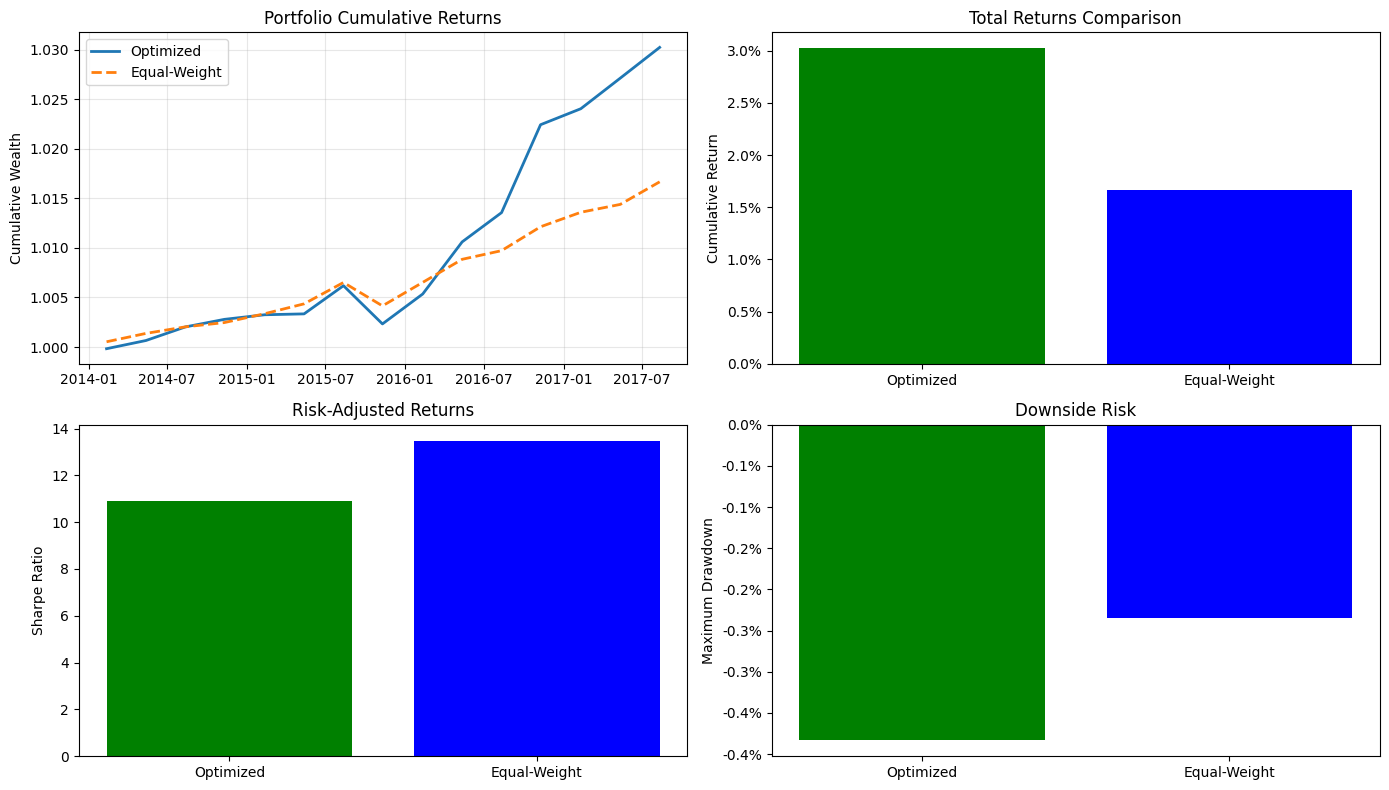

In [18]:
# Backtest visualization
opt_cumulative = (1 + opt_returns_series).cumprod()
eq_cumulative = (1 + equal_returns_series).cumprod()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Cumulative returns
axes[0, 0].plot(opt_cumulative.index, opt_cumulative.values, label='Optimized', linewidth=2)
axes[0, 0].plot(eq_cumulative.index, eq_cumulative.values, label='Equal-Weight', linewidth=2, linestyle='--')
axes[0, 0].set_ylabel('Cumulative Wealth')
axes[0, 0].set_title('Portfolio Cumulative Returns')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Total returns
axes[0, 1].bar(['Optimized', 'Equal-Weight'], [opt_cum_ret, eq_cum_ret], color=['green', 'blue'])
axes[0, 1].set_ylabel('Cumulative Return')
axes[0, 1].set_title('Total Returns Comparison')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

# Sharpe ratio
axes[1, 0].bar(['Optimized', 'Equal-Weight'], [opt_sharpe, eq_sharpe], color=['green', 'blue'])
axes[1, 0].set_ylabel('Sharpe Ratio')
axes[1, 0].set_title('Risk-Adjusted Returns')

# Max drawdown
axes[1, 1].bar(['Optimized', 'Equal-Weight'], [opt_max_dd, eq_max_dd], color=['green', 'blue'])
axes[1, 1].set_ylabel('Maximum Drawdown')
axes[1, 1].set_title('Downside Risk')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

plt.tight_layout()
plt.show()

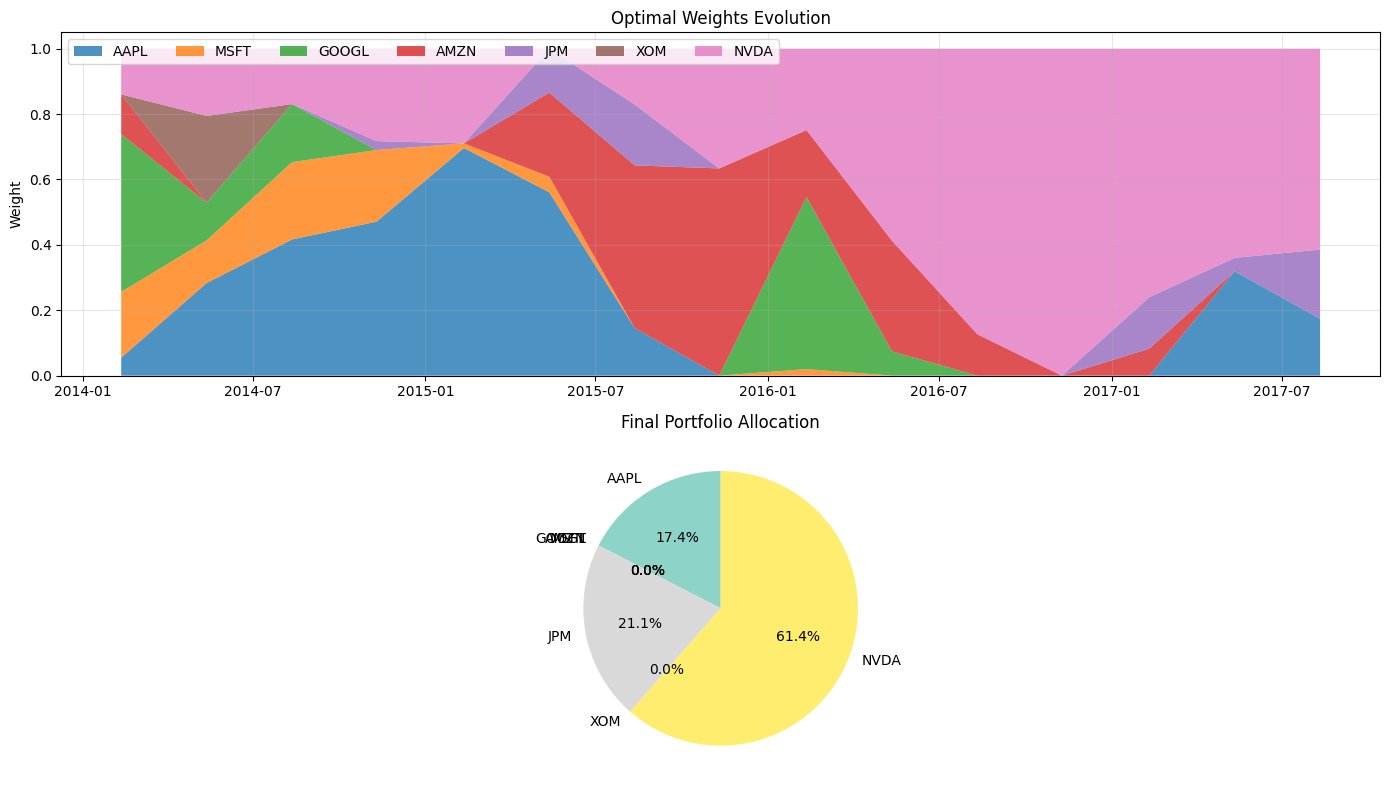


Final Optimal Allocation:
----------------------------------------
AAPL         17.42%
MSFT          0.00%
GOOGL         0.00%
AMZN          0.00%
JPM          21.14%
XOM           0.00%
NVDA         61.44%


In [19]:
# Portfolio weights evolution
weights_df = pd.DataFrame(optimized_weights_history, columns=stocks, index=dates_history)
final_weights = optimized_weights_history[-1] if optimized_weights_history else np.array([1/len(stocks)]*len(stocks))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Stacked area
axes[0].stackplot(weights_df.index, [weights_df[stock].values for stock in stocks], 
                   labels=stocks, alpha=0.8)
axes[0].set_ylabel('Weight')
axes[0].set_title('Optimal Weights Evolution')
axes[0].legend(loc='upper left', ncol=7)
axes[0].grid(True, alpha=0.3)

# Final allocation pie
colors = plt.cm.Set3(np.linspace(0, 1, len(stocks)))
axes[1].pie(final_weights, labels=stocks, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Final Portfolio Allocation')

plt.tight_layout()
plt.show()

print("\nFinal Optimal Allocation:")
print("-"*40)
for stock, weight in zip(stocks, final_weights):
    print(f"{stock:<10} {weight:>8.2%}")

In [20]:
# Sensitivity analysis - risk-free rate impact
risk_free_rates = np.array([0.01, 0.02, 0.03, 0.04, 0.05]) / 252
results_sensitivity = []

train_data = backtest_data.iloc[-252:].copy()
recent_mean_returns = train_data.mean()

for rf_rate in risk_free_rates:
    def neg_sharpe_sens(weights, mean_ret, cov_mat, rf):
        portfolio_return = np.sum(mean_ret * weights)
        portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
        sharpe_ratio = (portfolio_return - rf) / portfolio_std if portfolio_std > 0 else 0
        return -sharpe_ratio
    
    result = minimize(neg_sharpe_sens, init_guess,
                     args=(recent_mean_returns, train_data.cov(), rf_rate),
                     method='SLSQP', bounds=bounds, constraints=constraints)
    
    opt_w = result.x
    port_ret = np.sum(recent_mean_returns * opt_w)
    port_std = np.sqrt(np.dot(opt_w.T, np.dot(train_data.cov(), opt_w)))
    sharpe = (port_ret - rf_rate) / port_std if port_std > 0 else 0
    
    results_sensitivity.append({
        'rf_rate': rf_rate * 252 * 100,
        'sharpe': sharpe,
        'return': port_ret * 252 * 100,
        'std': port_std * np.sqrt(252) * 100
    })

sensitivity_df = pd.DataFrame(results_sensitivity)
print("\nSensitivity to Risk-Free Rate:")
print("-"*60)
print(sensitivity_df.to_string(index=False))


Sensitivity to Risk-Free Rate:
------------------------------------------------------------
 rf_rate   sharpe    return       std
     1.0 0.190334 47.315757 15.328930
     2.0 0.186239 47.639270 15.437186
     3.0 0.182169 47.920419 15.533488
     4.0 0.178125 48.215258 15.636781
     5.0 0.174109 48.524684 15.747571


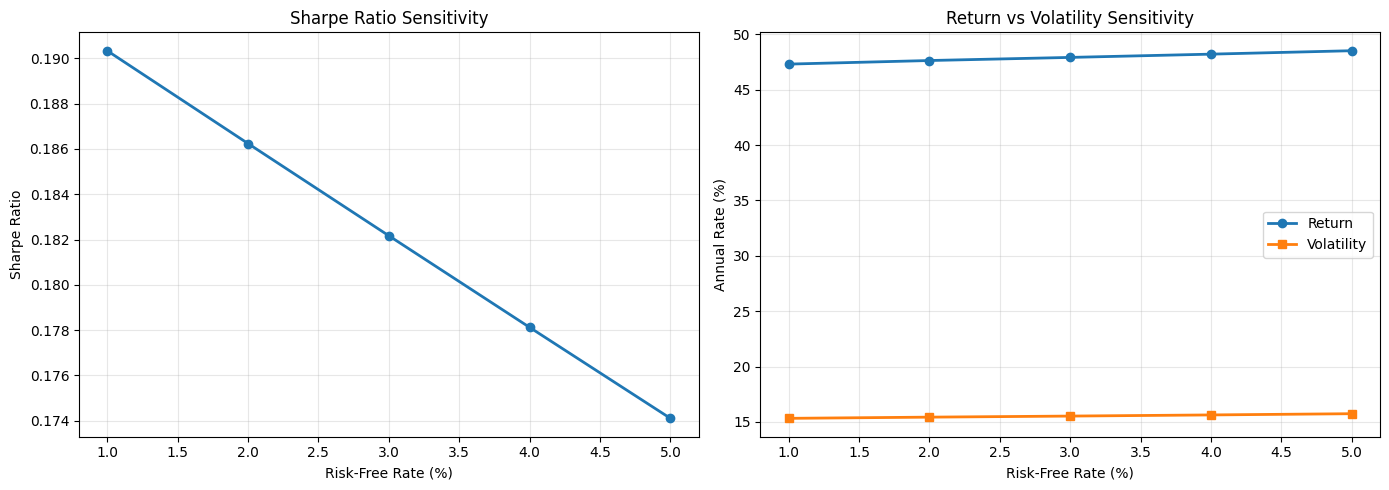

In [21]:
# Sensitivity visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sensitivity_df['rf_rate'], sensitivity_df['sharpe'], marker='o', linewidth=2)
axes[0].set_xlabel('Risk-Free Rate (%)')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].set_title('Sharpe Ratio Sensitivity')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sensitivity_df['rf_rate'], sensitivity_df['return'], marker='o', label='Return', linewidth=2)
axes[1].plot(sensitivity_df['rf_rate'], sensitivity_df['std'], marker='s', label='Volatility', linewidth=2)
axes[1].set_xlabel('Risk-Free Rate (%)')
axes[1].set_ylabel('Annual Rate (%)')
axes[1].set_title('Return vs Volatility Sensitivity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Constraint testing
constraints_list = [
    ('Unconstrained', tuple((0, 1) for _ in range(len(stocks)))),
    ('Max 30%', tuple((0, 0.3) for _ in range(len(stocks)))),
    ('Max 20%', tuple((0, 0.2) for _ in range(len(stocks)))),
    ('Min 5%', tuple((0.05, 1) for _ in range(len(stocks))))
]

constraint_results = []
for constraint_name, bounds_c in constraints_list:
    result_c = minimize(neg_sharpe, init_guess,
                       args=(recent_mean_returns, train_data.cov()),
                       method='SLSQP', bounds=bounds_c, constraints=constraints)
    
    opt_w_c = result_c.x
    port_ret = np.sum(recent_mean_returns * opt_w_c) * 252
    port_std = np.sqrt(np.dot(opt_w_c.T, np.dot(train_data.cov(), opt_w_c))) * np.sqrt(252)
    sharpe = (port_ret - 0.02) / port_std if port_std > 0 else 0
    
    constraint_results.append({
        'Constraint': constraint_name,
        'Return': port_ret,
        'Volatility': port_std,
        'Sharpe': sharpe
    })

constraint_df = pd.DataFrame(constraint_results)
print("\nConstraint Impact Analysis:")
print("="*60)
print(constraint_df.to_string(index=False))


Constraint Impact Analysis:
   Constraint   Return  Volatility   Sharpe
Unconstrained 0.476393    0.154372 2.956450
      Max 30% 0.439225    0.147124 2.849467
      Max 20% 0.427844    0.159634 2.554867
       Min 5% 0.427360    0.145739 2.795129


In [23]:
print("\n✓ Backtesting & Advanced Analysis Complete")


✓ Backtesting & Advanced Analysis Complete


In [24]:
# Save backtesting results for app.ipynb
import json
import pickle

# Save metrics
metrics = {
    'opt_cum_ret': float(opt_cum_ret),
    'opt_sharpe': float(opt_sharpe),
    'opt_max_dd': float(opt_max_dd),
    'eq_cum_ret': float(eq_cum_ret),
    'eq_sharpe': float(eq_sharpe),
    'eq_max_dd': float(eq_max_dd),
    'num_periods': len(dates_history)
}
with open('backtest_metrics.json', 'w') as f:
    json.dump(metrics, f)

# Save arrays
np.save('optimized_returns.npy', np.array(optimized_returns))
np.save('equal_weight_returns.npy', np.array(equal_weight_returns))
np.save('final_weights.npy', np.array(final_weights))

# Save dates
dates_str = [str(d) for d in dates_history]
with open('dates_history.json', 'w') as f:
    json.dump(dates_str, f)

# Save Series as CSV
opt_returns_series.to_csv('opt_returns_series.csv')
equal_returns_series.to_csv('equal_returns_series.csv')
weights_df.to_csv('weights_evolution.csv')

print("✓ Backtesting results saved for app.ipynb")

✓ Backtesting results saved for app.ipynb
